# Method Selection and Final Evaluation

Generated from `notebooks/DELE_CA1_B.ipynb` by `scripts/split_notebook.py`.


---
# 10. Method Selection & Final Model Evaluation

In this section, we will be defining our problem statement and reasoning on the Method we are selecting (Classification or Regression) and subsequently, we will perfrom further Evaluation and Analysis on the Best Model for the Method chosen.

---
## 10.1 Problem Statement

In the context of movie review platforms, users are typically more interested in quickly understanding whether a review expresses a positive or negative opinion, rather than interpreting a numerical sentiment score. Predicting a sentiment label (e.g., Positive or Negative) offers a more intuitive and accessible summary for users who rely on reviews to make viewing decisions.

However, existing systems that rely on numerical sentiment scores can lead to ambiguity, as users may not always understand how to interpret mid-range values (e.g., 0.56 or 0.67) or how those values correlate with actual viewer satisfaction. This can hinder decision-making, especially for casual users or those unfamiliar with sentiment scoring systems.

Thus, this project aims to build a robust binary sentiment classification model that transforms user-generated reviews into clear and interpretable labels. The goal is to enhance the user experience on movie review platforms by offering straightforward sentiment insights that support faster, more confident movie selections.

---
## 10.2 Best Classification Model Summary

In this sub-section, we will be producing the Summary of the GRU Classification Model so as to understand the complexity and layers of the Model. This will allow us to view the various Layers and the various Weights of each layer.

In [ ]:
# ==================== Load the Best Performing Classification Model ==================== #
best_model_path = "Models/gru_classification.keras"
best_model = load_model(best_model_path)

# ==================== Display Model Summary ==================== #
best_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 300)       │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 100, 512)       │       857,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 100, 512)       │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 100, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 128)            │       221,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,317,765 (46.99 MB)

 Trainable params: 4,105,409 (15.66 MB)

 Non-trainable params: 1,536 (6.00 KB)

 Optimizer params: 8,210,820 (31.32 MB)

With reference to the output of the Summary above, we are able to see that our GRU Classification RNN Model has a total of 15 Layers. The various weights will be submitted as part of the assignment.

---
## 10.3 Best Classification Model Architecture

In this sub-section, we will be visualising the various layers of the GRU Classification RNN Model. The visualisation will show various information such as the Input Shape and Output Shape. This will allow for a better understanding of our Model's Architecture as compared to the Summary as the Visualisation is more streamlined and only displays the important information.

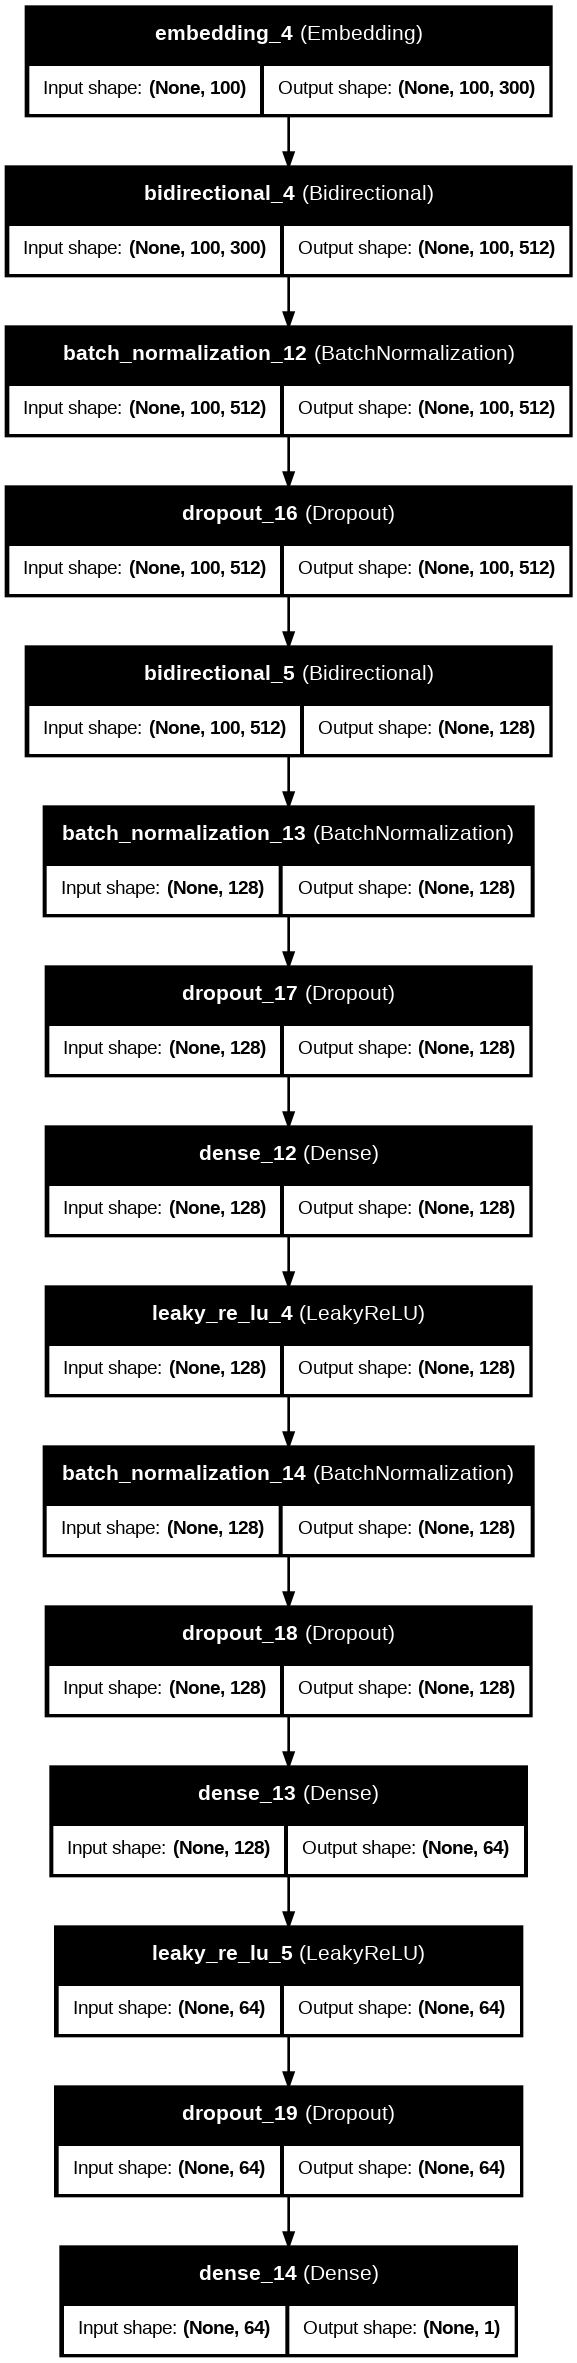

In [ ]:
# ======================== Plotting Architecture ======================== #
plot_model(
    best_model,
    to_file="gru_classification_architecture.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=96
)

# ======================== Displaying Architecture ======================== #
display(Image("gru_classification_architecture.png"))

With reference to the output above, we are able to see the Model's Architecture and the various Input and Output Shape. This allows us to view the Model's input data and also potentially plan for future development should we have more Data or need to increase the complexity of the GRU Classification RNN Model.

---
## 10.4 3D t-SNE Projection of Penultimate Layer Embeddings (GRU Classification RNN)

In this sub-section, we will be visualising the Best Model's high-dimesional feature space learnt by the model right before the final classification layer. We will be using t-SNE for visualisation due to the high dimensions and subsequently plot on a 3D Scatter Plot. The potential observations that can be made are listed below.

**Well-separated Clusters**

- The model has learned distinct embeddings for different sentiment classes.
High inter-class separability (better generalisation and classification confidence).

**Overlapping Clusters**

- Similarity between classes
- Confusion likely in the model predictions.
- Potential benefit from more data, augmentation, or deeper networks.

With the potential obervations listed and its meaning, we will proceed to conduct the visualisation in the Code Cell below.

In [ ]:
# ==================== Load the Saved Sequential Model ==================== #
model = load_model("Models/gru_classification.keras")

# ==================== Create a New Model from Penultimate Layer ==================== #
input_layer = Input(shape=(X_test_class_pad.shape[1],))
x = model.layers[0](input_layer)

for layer in model.layers[1:-1]:
    x = layer(x)

penultimate_model = Model(inputs=input_layer, outputs=x)

# ==================== Generate Embeddings from Penultimate Layer ==================== #
penultimate_embeddings = penultimate_model.predict(X_test_class_pad)
effective_perplexity = min(20, len(penultimate_embeddings) // 2)  # safe default

# ==================== Run 3D t-SNE ==================== #
tsne = TSNE(n_components=3, perplexity=effective_perplexity, n_iter=3000, random_state=42)
tsne_3d = tsne.fit_transform(penultimate_embeddings)

# ==================== Create DataFrame ==================== #
tsne_df = pd.DataFrame({
    'TSNE-1': tsne_3d[:, 0],
    'TSNE-2': tsne_3d[:, 1],
    'TSNE-3': tsne_3d[:, 2],
    'Sentiment': y_test_class.astype(str)
})

# ==================== Visualise ==================== #
fig = px.scatter_3d(
    tsne_df,
    x='TSNE-1', y='TSNE-2', z='TSNE-3',
    color='Sentiment',
    title="3D t-SNE Projection of Penultimate GRU Layer Embeddings",
    color_discrete_sequence=px.colors.qualitative.Safe
)

fig.update_layout(template='plotly_white', title_font=dict(size=20))
fig.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



With reference to the output of the t-SNE Visualisation above, we are able to observe the various clusters are **Well-Separated** which implies that the Model did classify accuractely and to a high standard. However, there are a few outliers within the plot but these outliers are minor and do not impose a heavy deduction in accuracy towards the model.

---
## 10.5 Visualising Overall Architecture

In this sub-section, we will be visualising the Overall Architecture of the Best Model. This will allow for a very vague overview of the Model's architecture without much information on weights and inputs or outputs which will be more friendly towards audience with no AI background. This will also allow us to see the Model's process in one view.

/usr/local/lib/python3.11/dist-packages/visualkeras/layered.py:86: UserWarning:

The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.



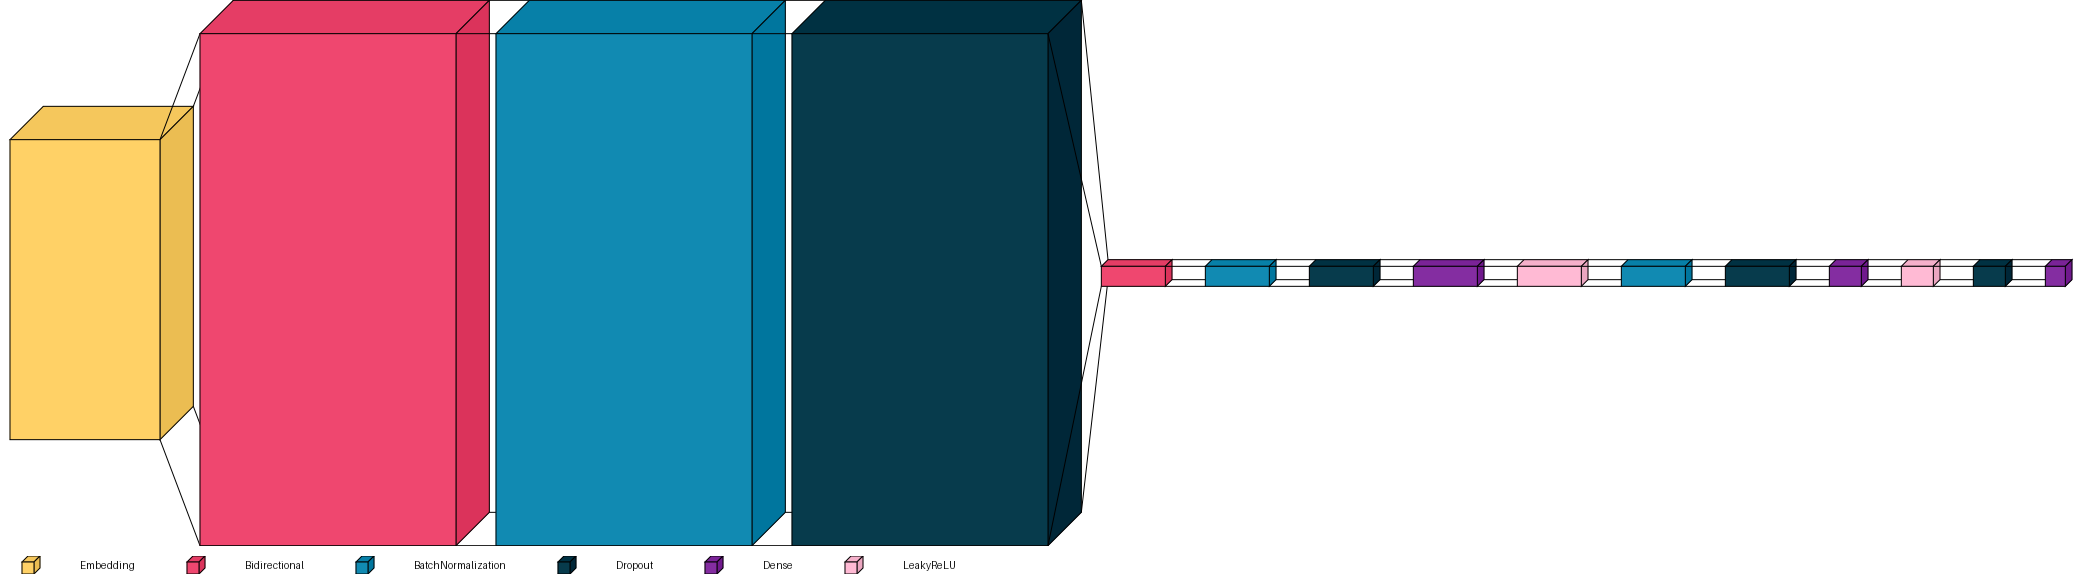

In [ ]:
# ==================== Producing 3D‐block View ==================== #
visualkeras.layered_view(
    best_model,
    to_file='model_3d.png',
    legend=True,
    spacing=40,
    scale_xy=1.0,
    scale_z=0.5
)

# ==================== Displaying 3D‐block View ==================== #
Image('model_3d.png')

With reference to the output of the Model's Achitecture above, we are able to see that the Model has multiple layers before the output. We are also able to see the sequence in which the process is taking place.

---
# 11. Bibliographies

Bikmukhametov, T. (2025). LinkedIn. [online] Linkedin.com. Available at: https://www.linkedin.com/posts/timurbikmukhametov_guide-to-neural-network-hyperparam-tuning-activity-7310995211281653760-JMbR?utm_source=share&utm_medium=member_desktop&rcm=ACoAAE7GRTUBBHsPcBm6fIan901ng_k_JOl7PsU [Accessed 17 May 2025].
<br>
<br>
Géron, A. (2019). Hands-on machine learning with Scikit-Learn and TensorFlow concepts, tools, and techniques to build intelligent systems. 2nd ed. O’Reilly Media, Inc.
<br>
<br>
OpenAI. (2023). ChatGPT.
<br>
<br>
TensorFlow (2025). The Sequential model | TensorFlow Core. [online] TensorFlow. Available at: https://www.tensorflow.org/guide/keras/sequential_model.
<br>
<br>
Russel, S. and Norvig, P. (2020). Artificial intelligence: A Modern approach. 4th ed. Prentice Hall.